# Día 7 (17/12/2025)

## Temario:
- Manipulación de Datos
- Limpieza de datos
- Introducción a la Regresión Lineal

In [1]:
# ----------------------------------- Datos ------------------------------------
import pandas as pd
import numpy as np

In [2]:
data = {
    "Nombre": ["Ana", "Juan", "Pedro", "María", "Luis", None],
    "Edad": [23, 35, None, 29, 41, 30],
    "Ciudad": ["CDMX", "cdmx", "Monterrey", "GDL", " gdl", "CDMX"],
    "Ingresos": ["$12,000", "$18,500", "$15,300", None, "$22000.", "$17800."]
    }

## **Manipulación de Datos**

In [3]:
# Nota: para importar un .csv se utiliza: variable = pd.read_csv("NombreArchivo.csv")
df = pd.DataFrame(data)
df

,Nombre,Edad,Ciudad,Ingresos
0,Ana,23.0,CDMX,"$12,000"
1,Juan,35.0,cdmx,"$18,500"
2,Pedro,NaN,Monterrey,"$15,300"
3,María,29.0,GDL,None
4,Luis,41.0,gdl,$22000.
5,None,30.0,CDMX,$17800.


¿Qué es un **DataFrame**? R= Es una tabla de datos: filas (registros) y columnas (variables)

In [4]:
# Exploración de los Datos
df.head() # jala los primeros 5 valores

,Nombre,Edad,Ciudad,Ingresos
0,Ana,23.0,CDMX,"$12,000"
1,Juan,35.0,cdmx,"$18,500"
2,Pedro,NaN,Monterrey,"$15,300"
3,María,29.0,GDL,None
4,Luis,41.0,gdl,$22000.


In [5]:
# Si deseas ver las columnas puedes hacerlo con:
df.columns

Index(['Nombre', 'Edad', 'Ciudad', 'Ingresos'], dtype='object')

In [6]:
# Conocer el tipo de datos que se esta trabajando:
df.info() # objeto = string

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Nombre    5 non-null      object 
 1   Edad      5 non-null      float64
 2   Ciudad    6 non-null      object 
 3   Ingresos  5 non-null      object 
dtypes: float64(1), object(3)
memory usage: 324.0+ bytes


In [7]:
df.describe(include="all") # si no colocas nada, te arroja solo datos numéricos

,Nombre,Edad,Ciudad,Ingresos
count,5,5.00000,6,5
unique,5,NaN,5,5
top,Ana,NaN,CDMX,"$12,000"
freq,1,NaN,2,1
mean,NaN,31.60000,NaN,NaN
std,NaN,6.76757,NaN,NaN
min,NaN,23.00000,NaN,NaN
25%,NaN,29.00000,NaN,NaN
50%,NaN,30.00000,NaN,NaN
75%,NaN,35.00000,NaN,NaN


In [8]:
df['Edad'] # traer solo esa columna en específico

,Edad
0,23.0
1,35.0
2,NaN
3,29.0
4,41.0
5,30.0


In [9]:
df[df['Edad']>30] # datos existentes que cumplan con esa condición

,Nombre,Edad,Ciudad,Ingresos
1,Juan,35.0,cdmx,"$18,500"
4,Luis,41.0,gdl,$22000.


In [10]:
print(df)
df[
    (df["Edad"] > 18) &
    (df["Ingresos"]!= "$22,000") & # una coma hace la diferencia por ser un string
    (df["Nombre"] != "Juan")
]

  Nombre  Edad     Ciudad Ingresos
0    Ana  23.0       CDMX  $12,000
1   Juan  35.0       cdmx  $18,500
2  Pedro   NaN  Monterrey  $15,300
3  María  29.0        GDL     None
4   Luis  41.0        gdl  $22000.
5   None  30.0       CDMX  $17800.


,Nombre,Edad,Ciudad,Ingresos
0,Ana,23.0,CDMX,"$12,000"
3,María,29.0,GDL,None
4,Luis,41.0,gdl,$22000.
5,None,30.0,CDMX,$17800.


In [11]:
# Uso de count(), mean(), sum(), fillna(), str.replace(), astype()
print(df["Edad"].count()) # son 6 pero 1 es None entonces son 5
print("")
print(df["Edad"].mean()) # promedio de edades
print("")
print(df["Edad"].sum()) # suma de los datos
print("----------------------------------")
print(df["Nombre"].fillna("Desconocido")) # reemplaza los valores nulos
print("----------------------------------")
print(df["Ingresos"].str.replace("$", "").str.replace(",", "").astype(float))
# str.replace reemplaza "x" símbolo por "y"
# .astype(tipo_de_dato) cambia el tipo de dato de tu columna

5

31.6

158.0
----------------------------------
0            Ana
1           Juan
2          Pedro
3          María
4           Luis
5    Desconocido
Name: Nombre, dtype: object
----------------------------------
0    12000.0
1    18500.0
2    15300.0
3        NaN
4    22000.0
5    17800.0
Name: Ingresos, dtype: float64


## **Limpieza de Datos**

In [12]:
df_clean = df.copy()
print(df_clean)
# Rellenar valores faltantes
df_clean["Nombre"] = df_clean["Nombre"].fillna("Desconocido")
df_clean["Edad"] = df_clean["Edad"].fillna(df_clean["Edad"].mean())
df_clean["Ingresos"] = df_clean["Ingresos"].fillna("$0")
df_clean

  Nombre  Edad     Ciudad Ingresos
0    Ana  23.0       CDMX  $12,000
1   Juan  35.0       cdmx  $18,500
2  Pedro   NaN  Monterrey  $15,300
3  María  29.0        GDL     None
4   Luis  41.0        gdl  $22000.
5   None  30.0       CDMX  $17800.


,Nombre,Edad,Ciudad,Ingresos
0,Ana,23.0,CDMX,"$12,000"
1,Juan,35.0,cdmx,"$18,500"
2,Pedro,31.6,Monterrey,"$15,300"
3,María,29.0,GDL,$0
4,Luis,41.0,gdl,$22000.
5,Desconocido,30.0,CDMX,$17800.


In [13]:
print(df)
print(df_clean)

  Nombre  Edad     Ciudad Ingresos
0    Ana  23.0       CDMX  $12,000
1   Juan  35.0       cdmx  $18,500
2  Pedro   NaN  Monterrey  $15,300
3  María  29.0        GDL     None
4   Luis  41.0        gdl  $22000.
5   None  30.0       CDMX  $17800.
        Nombre  Edad     Ciudad Ingresos
0          Ana  23.0       CDMX  $12,000
1         Juan  35.0       cdmx  $18,500
2        Pedro  31.6  Monterrey  $15,300
3        María  29.0        GDL       $0
4         Luis  41.0        gdl  $22000.
5  Desconocido  30.0       CDMX  $17800.


In [14]:
df_clean["Ciudad"] = (
    df_clean["Ciudad"]
    .str.lower() # todo en minúsculas o .upper para mayúsculas
    .str.strip() # quitar espacios
)

**Ejercicio**: Ahora que podemos trabajar con los datos limpios:
1. Obtenga los nombres
2. Obtenga los nombres sin "Desconocido"
3. Obtenga la cantidad de personas que hay por ciudad
4. Nivel díficil: Obtenga todos los datos que no son "Desconocido", personas que no sean de "monterrey" y que tengan un ingreso mayor a cero
5. Obtenga la edad promedio de las personas que no son de la Ciudad de México que tienen un ingreso mayor o igual a $10,000

In [15]:
# 1
df_clean["Nombre"]

,Nombre
0,Ana
1,Juan
2,Pedro
3,María
4,Luis
5,Desconocido


In [16]:
# 2
df_clean[df_clean["Nombre"] != "Desconocido"]["Nombre"]

,Nombre
0,Ana
1,Juan
2,Pedro
3,María
4,Luis


In [17]:
# 3
df_clean["Ciudad"].value_counts() # contador por ciudad

,count
Ciudad,
cdmx,3
gdl,2
monterrey,1


In [18]:
# 4
df_clean[(df_clean["Nombre"] != "Desconocido") & (df_clean["Ciudad"] != "monterrey") & (df_clean["Ingresos"] != "$0")]

,Nombre,Edad,Ciudad,Ingresos
0,Ana,23.0,cdmx,"$12,000"
1,Juan,35.0,cdmx,"$18,500"
4,Luis,41.0,gdl,$22000.


In [19]:
# 5 edad promedio que ganan >=$10,000 y no son de cdmx
df_clean[(df_clean["Ingresos"] >= "$10,000") & (df_clean["Ciudad"] != "cdmx")]["Edad"].mean()

np.float64(36.3)

In [20]:
# cambiar tipo de dato ["ingresos"] (string a float)
# df_clean["Ingresos"] = df_clean["Ingresos"].str.replace("$", "").str.replace(",", "").astype(float)
df_clean["Ingresos"] = (
    df_clean["Ingresos"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
    .fillna(0)
)

In [21]:
df_clean

,Nombre,Edad,Ciudad,Ingresos
0,Ana,23.0,cdmx,12000.0
1,Juan,35.0,cdmx,18500.0
2,Pedro,31.6,monterrey,15300.0
3,María,29.0,gdl,0.0
4,Luis,41.0,gdl,22000.0
5,Desconocido,30.0,cdmx,17800.0


## Introducción a la **Regresión Lineal**
- ¿Qué es una regresión? R= Una regresión intenta predecir un valor numérico a partir de un histórico, la más simple es la regresión lineal.

Ejemplo:
- Predecir ingresos según la edad (nuestros datos)
- Predecir precio según el año

In [22]:
from sklearn.linear_model import LinearRegression

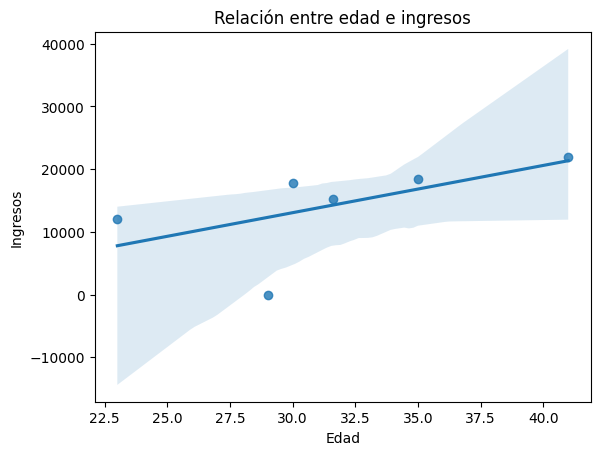

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x = df_clean["Edad"], y = df_clean["Ingresos"])
plt.xlabel("Edad")
plt.ylabel("Ingresos")
plt.title("Relación entre edad e ingresos")
plt.show()

In [24]:
# MATRIZ DE CORRELACIÓN
# df_clean.corr() sirve para una correlación, para saber si alguna variable es útil
df_clean[["Edad", "Ingresos"]].corr()

# 0.0 --> no hay correlación,
# 0.3 --> correlación débil,
# 0.5-0.7 --> correlación moderada # > 0.8 --> correlación fuerte

,Edad,Ingresos
Edad,1.000000,0.588779
Ingresos,0.588779,1.000000


In [25]:
x = df_clean[["Edad"]]
y = df_clean["Ingresos"]
modelo = LinearRegression()
modelo.fit(x, y)
# .fit busca los valores de m y b que mejor se ajustan a tus datos (y=mx+b);
# minimiza el error entre los ingresos reales y los predichos

LinearRegression()

In [26]:
edad_nueva=[[30]]
prediccion = modelo.predict(edad_nueva)
prediccion

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([13061.25181951])

In [27]:
# Podemos evaluar el modelo
from sklearn.metrics import r2_score, mean_squared_error
y_pred = modelo.predict(x) # Son los ingresos que el modelo cree según la edad
# ingresos = beta0 + beta1 * edad
# beta0 -> intercepto
# beta1 -> coeficiente de edad

r2 = r2_score(y, y_pred)
# 0.3-0.5 es aceptable, 0.6-0.8 es bueno y > 0.8 es muy bueno

mse = mean_squared_error(y, y_pred)
# Mean Squared Error (MSE) = Error Cuadrático Medio
# promedio de los errores al cuadrado entre los valores reales y los valores predichos por un modelo
# indica qué tan dispersos están los errores; un MSE bajo sugiere un mejor ajuste del modelo

print("R2:", r2)
print("MSE:", mse)

# Para Regresión Logística se suele usar -> Accuracy, Precision, F1 Score, Recall, Roc Auc

R2: 0.34666091920946085
MSE: 32661872.513343036
